In [79]:
from dlfs.base import Module, Loss, Optimizer, Layer

from dlfs.modules import SequentialWrapper
from dlfs.layers import DenseLayer, ConvolutionalLayer
from dlfs.activation import ReLU, Sigmoid

from dlfs.loss import MSE_Loss, BCE_Loss
from dlfs.optimizers import Optimizer_Adam
from dlfs.helpers import im2col, col2im, im2col_strided, col2im_strided, get_random_batch, load_mnist, select_specific_labels, preprocess_whole_mnist

import numpy as np
import matplotlib.pyplot as plt

In [80]:
class ConvLayer(Layer):

    def __init__(self, input_channels: tuple, output_channels: int, kernel_size: int, stride: int = 1, padding: int = 0) -> None:

        self.input_channels = input_channels
        self.output_channels = output_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding

        # Create output and kernel shapes
        self.kernel_size = kernel_size

        # Initialize layer parameters
        self.kernels = np.random.randn(output_channels, input_channels, kernel_size, kernel_size)
        self.biases = np.random.randn(output_channels)

    def forward(self, inputs, training=False):

        B, _, self.H_in, self.W_in = inputs.shape

        C_out, C_in, kH, kW = self.kernels.shape

        self.X_col, H_out, W_out = im2col(inputs, (kH, kW), stride=self.stride, padding=self.padding) # (B, C_in*kH*kW, H_out*W_out)

        self.K_col = self.kernels.reshape(C_out, -1) # (C_out, C_in*kH*kW)

        Y_col = self.K_col @ self.X_col + self.biases[None, :, None] # (B, C_out, H_out*W_out)

        Y = Y_col.reshape(B, C_out, H_out, W_out) # (B, C_out, H_out, W_out)

        self.output = Y

    def backward(self, delta):

        B, C_out, out_H, out_W = delta.shape
        C_out, C_in, kH, kW = self.kernels.shape

        delta_col = delta.reshape(B, C_out, -1) # (B, C_out, out_H*out_W)

        self.dkernels = delta_col @ self.X_col.transpose(0, 2, 1) # (B, C_out, C_in*kH*kW)
        self.dkernels = np.sum(self.dkernels, axis=0)
        self.dkernels = self.dkernels.reshape(self.kernels.shape)

        self.dinputs = self.K_col.T @ delta_col # (B, C_in*kH*kW, out_H*out_W)
        self.dinputs = col2im_strided(self.dinputs, 
                              output_shape=(self.H_in, self.W_in), 
                              kernel_shape=(kH, kW), 
                              stride=self.stride, 
                              padding=self.padding) # (B, C_in, H_in, W_in)

        self.dbiases = np.sum(delta_col, axis=(0, 2)) # (C_out)

    def get_parameters(self):
        param_names = ["kernels", "biases"]
        return super()._filter_parameters(param_names)

In [81]:
class ConvTransposeLayer(Layer):

    def __init__(self, input_channels: tuple, output_channels: int, kernel_size: int, stride: int = 1, padding: int = 0, output_padding=0) -> None:

        self.input_channels = input_channels
        self.output_channels = output_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.output_padding = output_padding

        # Create output and kernel shapes
        self.kernel_size = kernel_size

        # Initialize layer parameters
        self.kernels = np.random.randn(input_channels, output_channels, kernel_size, kernel_size)
        self.biases = np.random.randn(output_channels)

    def forward(self, inputs: np.ndarray, training=False) -> None:
        C_in, C_out, kH, kW = self.kernels.shape
        B, _, self.H_in, self.W_in = inputs.shape

        self.Y_col = inputs.reshape(B, C_in, -1) # (B, C_in, H_in*W_in)
        self.K_col = self.kernels.reshape(C_in, -1)  # (C_in, C_out*kH*kW)

        X_col = self.K_col.T @ self.Y_col # (B, C_out*kH*kW, H_in*W_in)

        H_out = (self.H_in - 1) * self.stride - 2 * self.padding + kH
        W_out = (self.W_in - 1) * self.stride - 2 * self.padding + kW

        X = col2im_strided(X_col, 
                   output_shape=(H_out, W_out), 
                   kernel_shape=(kH, kW), 
                   stride=self.stride, 
                   padding=self.padding) # (B, C_out, H_out, W_out)
    
        self.output = X + self.biases[None, :, None, None]

    def backward(self, delta: np.ndarray) -> None:
        
        B, C_out, out_H, out_W = delta.shape
        C_in, _, kH, kW = self.kernels.shape
        delta_col, _, _ = im2col(delta, kernel_shape=(kH, kW), stride=self.stride, padding=self.padding) # (B, C_out*kH*kW, H_out*W_out)

        self.dkernels = self.Y_col @ delta_col.transpose(0, 2, 1) # # (B, C_in, H_in*W_in) x (B, H_in*W_in, C_out*kH*kW) = (B, C_in, C_out*kH*kW)
        self.dkernels = np.sum(self.dkernels, axis=0)
        self.dkernels = self.dkernels.reshape(C_in, C_out, kH, kW)
        
        self.dinputs = self.K_col @ delta_col
        self.dinputs = self.dinputs.reshape(B, C_in, self.H_in, self.W_in)

        self.dbiases = np.sum(delta, axis=(0, 2, 3))

    def get_parameters(self):
        param_names = ["kernels", "biases"]
        return super()._filter_parameters(param_names)

In [82]:
class MaxPoolLayer(Layer):

    def __init__(self, pool_size: int | tuple, stride: int, padding: int):
        self.stride = stride
        self.padding = padding

        if isinstance(pool_size, tuple):
            self.pool_size = pool_size
        else:
            self.pool_size = (pool_size, pool_size)

    def forward(self, inputs, training=False):
        self.H_in, self.W_in = inputs.shape[-2:]
        B, C = inputs.shape[:2]
        kH, kW = self.pool_size

        cols, out_H, out_W = im2col_strided(inputs, kernel_shape=self.pool_size,
                                            stride=self.stride, padding=self.padding)

        self.cols_reshaped = cols.reshape(B, C, kH*kW, out_H*out_W)

        max_vals = np.max(self.cols_reshaped, axis=2)
        self.max_idx = np.argmax(self.cols_reshaped, axis=2)   # <--- NEEDED FOR BACKWARD

        pooled = max_vals.reshape(B, C, out_H, out_W)

        self.output = pooled

    def backward(self, delta):
        B, C, _, out_HW = self.cols_reshaped.shape
        kH, kW = self.pool_size

        delta_flat = delta.reshape(B, C, out_HW)
        
        dcols = np.zeros_like(self.cols_reshaped)

        # Scatter dout to positions of max values
        # max_idx has shape (B,C,out_HW); use advanced indexing
        b_idx = np.arange(B)[:, None, None]
        c_idx = np.arange(C)[None, :, None]
        hw_idx = np.arange(out_HW)[None, None, :]

        dcols[b_idx, c_idx, self.max_idx, hw_idx] = delta_flat

        # reshape back to original im2col shape
        dcols = dcols.reshape(B, C*kH*kW, out_HW)

        # convert col-gradients back to image
        dX = col2im_strided(dcols, output_shape=(self.H_in, self.W_in), kernel_shape=self.pool_size,
                            stride=self.stride, padding=self.padding)

        self.dinputs = dX

In [83]:
class UNet(Module):

    def __init__(self, encoder, decoder):
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, X, training=False):

        self.encoder.forward(X, training=training)
        self.decoder.forward(self.encoder.output, training=training)
        self.output = self.decoder.output

    def backward(self, delta):
        self.decoder.backward(delta)
        self.encoder.backward(self.decoder.dinputs)
        self.dinputs = self.encoder.dinputs

In [84]:
class Diffusion(Module):

    def __init__(self, model, image_size=28, image_channels=3, timesteps=1000, t_emb_dim=128, loss_function=None, optimizer=None):
        self.model = model
        self.timesteps = timesteps
        self.image_size = image_size

        self.betas = np.linspace(1e-4, 0.02, timesteps)
        self.alphas = 1 - self.betas
        self.alphas_cumprod = np.cumprod(self.alphas, axis=0)

        self.ac = np.sqrt(self.alphas_cumprod)
        self.om = np.sqrt(1 - self.alphas_cumprod)

        self.image_channels = image_channels
        self.t_emb_dim = t_emb_dim

        self.time_proj = DenseLayer(t_emb_dim, image_channels)

        self.loss_function = loss_function
        self.optimizer = optimizer

    def forward_diffusion(self, x0, t):
        batch_size = x0.shape[0]

        # Compute coefficients for each batch item
        # reshape to (batch, 1, 1, 1) for broadcasting
        ac_t = self.ac[t].reshape(-1, 1, 1, 1)
        om_t = self.om[t].reshape(-1, 1, 1, 1)

        # Sample noise of same shape as x0
        noise = np.random.randn(*x0.shape)

        # Forward diffusion formula
        x_t = ac_t * x0 + om_t * noise

        return x_t, noise

    def get_timestep_embedding(self, t, dim):
        t = t[:, None]  # (batch, 1)
        i = np.arange(dim//2, dtype=np.float32)
        freqs = 1.0 / (10000 ** (2 * i / dim))
        args = t * freqs  # (batch, dim//2)
        emb = np.concatenate([np.sin(args), np.cos(args)], axis=1)  # (batch, dim)
        return emb

    def add_noise_temb_to_img(self, x0):

        B, C = x0.shape[:2]

        # Generate random timesteps
        t = np.random.randint(0, self.timesteps, size=B)

        x_t, noise = self.forward_diffusion(x0, t)

        t_emb = self.get_timestep_embedding(t, dim=self.t_emb_dim)  # shape (batch, 128)

        # Simple linear projection of time embedding
        self.time_proj.forward(t_emb)
        temb_proj = self.time_proj.output[:, :, None, None]  # (batch, C, 1, 1)

        # Add time embedding to noisy image feature maps
        x_t_plus_temb = x_t + temb_proj

        return x_t_plus_temb, noise

    def forward(self, x, training=False):
        xt, noise = self.add_noise_temb_to_img(x)
        self.model.forward(xt, training=training)
        self.output = self.model.output
        self.noise_output = noise

    def backward(self, predicted, noise):

        self.loss_function.backward(predicted, noise)

        self.model.backward(self.loss_function.dinputs)
            # Gradient w.r.t temb_proj (broadcasted addition)
        grad_temb_proj = np.sum(self.model.dinputs, axis=(2,3))  # (B, C)

        # Backprop through time projection layer
        self.time_proj.backward(grad_temb_proj)

    def train(self, X: np.ndarray, epochs = 1000, batch_size: int = None, print_every: int = None) -> None:

        # Store loss values for plotting
        self.loss_vals = []

        for i in range(epochs + 1):

            if batch_size is not None:
                batch_X = get_random_batch(X, y, batch_size=batch_size)
            else:
                # If batch size is not specified take the whole dataset
                batch_X = X

            # Forward pass
            self.forward(batch_X, training=True)

            # Backward pass
            self.backward(self.output, self.noise_output)

            # Update parameters
            self.optimizer.pre_update_parameters()
            self.optimizer.update_parameters(self)
            self.optimizer.post_update_parameters()

            # Store current loss
            loss = self.loss_function.calculate(self.output, batch_X)
            self.loss_vals.append(loss)

            if print_every is not None and not i % print_every:
                print(f'===== EPOCH : {i} ===== LOSS : {loss} =====')

    def generate(self, B, C, H, W):
        
        x_t = np.random.randn(B, C, H, W).astype(np.float32)  # start from pure Gaussian noise

        for t in reversed(range(self.timesteps)):
            t_arr = np.array([t] * B)
            
            # Compute timestep embedding
            t_emb = self.get_timestep_embedding(t_arr, dim=self.t_emb_dim)
            
            # Project time embedding
            self.time_proj.forward(t_emb)
            temb_proj = self.time_proj.output[:, :, None, None]  # broadcast to (B, C, 1, 1)
            
            # Prepare input for network
            x_input = x_t + temb_proj
            
            # Predict noise
            self.model.forward(x_input, training=False)
            epsilon_pred = self.model.output
            
            # DDPM reverse diffusion formula
            alpha_t = self.alphas[t]
            alpha_cumprod_t = self.alphas_cumprod[t]
            beta_t = self.betas[t]
            
            # Predict mean of x_{t-1}
            mean = (1 / np.sqrt(alpha_t)) * (x_t - (beta_t / np.sqrt(1 - alpha_cumprod_t)) * epsilon_pred)
            
            # Sample x_{t-1} with noise if t > 0
            if t > 0:
                noise = np.random.randn(*x_t.shape)
                x_t = mean + np.sqrt(beta_t) * noise
            else:
                x_t = mean

        generated_images = x_t  # shape: (B, C, H, W)
        #images_uint8 = (np.clip(generated_images, 0, 1) * 255).astype(np.uint8)

        return generated_images

In [85]:
encoder = SequentialWrapper([
    ConvLayer(input_channels=1, output_channels=6, kernel_size=3, stride=1, padding=1),
    ReLU(),
    ConvLayer(input_channels=6, output_channels=6, kernel_size=3, stride=1, padding=1),
    ReLU(),
    MaxPoolLayer(pool_size=2, stride=2, padding=0)
])

decoder = SequentialWrapper([
    ConvTransposeLayer(input_channels=6, output_channels=1, kernel_size=4, stride=2, padding=1),
    ReLU()
])

unet = UNet(encoder=encoder, decoder=decoder)

In [86]:
path_train_data = "../data/mnist/train-images.idx3-ubyte"
path_train_labels = "../data/mnist/train-labels.idx1-ubyte"

path_test_data = "../data/mnist/t10k-images.idx3-ubyte"
path_test_labels = "../data/mnist/t10k-labels.idx1-ubyte"

X_train, y_train, X_test, y_test = load_mnist(path_train_data, path_train_labels, path_test_data, path_test_labels)

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test: {X_test.shape}, y_test: {y_test.shape}')

X_train: (60000, 28, 28), y_train: (60000,)
X_test: (10000, 28, 28), y_test: (10000,)


In [87]:
# Selecting images of 0s and 3s
X_train, _ = select_specific_labels(X_train, y_train, labels=[3], limit=250)
X_train = preprocess_whole_mnist(X_train)
X_train = np.expand_dims(X_train, axis=1)

print(f'X_train: {X_train.shape}')

X_train: (250, 1, 28, 28)


In [88]:
lr=1e-3
epochs=1000

loss = MSE_Loss()
optimizer = Optimizer_Adam(learning_rate=lr)

diffusion = Diffusion(model=unet, image_channels=1, loss_function=loss, optimizer=optimizer)

diffusion.train(X_train, print_every=10)

===== EPOCH : 0 ===== LOSS : 3232.2948712527364 =====
===== EPOCH : 10 ===== LOSS : 1417.2315382955596 =====
===== EPOCH : 20 ===== LOSS : 756.032679617335 =====
===== EPOCH : 30 ===== LOSS : 461.0129397530831 =====
===== EPOCH : 40 ===== LOSS : 303.89642030153567 =====
===== EPOCH : 50 ===== LOSS : 209.81651209263478 =====
===== EPOCH : 60 ===== LOSS : 151.7534703130965 =====
===== EPOCH : 70 ===== LOSS : 125.25485738228694 =====
===== EPOCH : 80 ===== LOSS : 95.64500120050491 =====
===== EPOCH : 90 ===== LOSS : 91.14067807399003 =====
===== EPOCH : 100 ===== LOSS : 71.79135017040039 =====
===== EPOCH : 110 ===== LOSS : 69.65831842640304 =====
===== EPOCH : 120 ===== LOSS : 61.03981621264336 =====
===== EPOCH : 130 ===== LOSS : 54.5401459011635 =====
===== EPOCH : 140 ===== LOSS : 44.62632181120638 =====
===== EPOCH : 150 ===== LOSS : 43.92541203977951 =====
===== EPOCH : 160 ===== LOSS : 39.90190420421259 =====
===== EPOCH : 170 ===== LOSS : 34.65380606620274 =====
===== EPOCH : 180 

KeyboardInterrupt: 

In [89]:
new_images = diffusion.generate(10, 1, 28, 28)

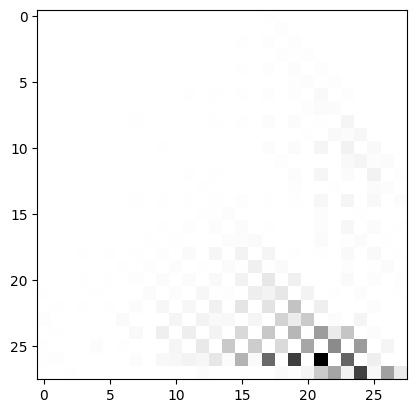

In [126]:
idx = np.random.randint(10)

img = new_images[idx] * 255
img = img.reshape(28, 28)

plt.imshow(img, cmap='gray')
plt.show()